In [19]:
import pandas as pd
import random

education_levels = ['Bachelors', 'Masters', 'PhD']
job_roles = [
    'Intern', 'Junior Developer', 'Software Engineer', 'Senior Developer',
    'Data Analyst', 'Data Scientist', 'QA Engineer', 'Product Manager',
    'Team Lead', 'Manager', 'Senior Manager', 'Director'
]

dataset = []

for i in range(120):
    age = random.randint(21, 55)
    experience = max(0, age - random.randint(21, 27))
    education = random.choices(education_levels, weights=[0.5, 0.3, 0.2])[0]
    job = random.choice(job_roles)
    hours = random.randint(38, 55)

    salary = 20000 + (experience * 4000)

    if education == 'Masters':
        salary += 15000
    elif education == 'PhD':
        salary += 30000

    if 'Senior' in job:
        salary += 25000
    elif 'Manager' in job:
        salary += 40000
    elif 'Director' in job:
        salary += 60000
    elif 'Intern' in job:
        salary -= 10000

    if hours > 45:
        salary += 5000

    salary += random.randint(-7000, 7000)

    dataset.append([age, education, experience, job, hours, salary])

df = pd.DataFrame(dataset, columns=[
    'Age', 'Education', 'Experience', 'JobRole', 'HoursPerWeek', 'Salary'
])

print(df.head())

   Age  Education  Experience            JobRole  HoursPerWeek  Salary
0   33        PhD          10  Software Engineer            43   90897
1   21    Masters           0           Director            41   88350
2   52    Masters          31          Team Lead            55  167324
3   23  Bachelors           2            Manager            47   78372
4   38    Masters          11       Data Analyst            51   87716


# Basic EDA

In [20]:
print("Dataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Age           120 non-null    int64 
 1   Education     120 non-null    object
 2   Experience    120 non-null    int64 
 3   JobRole       120 non-null    object
 4   HoursPerWeek  120 non-null    int64 
 5   Salary        120 non-null    int64 
dtypes: int64(4), object(2)
memory usage: 5.8+ KB
None


In [21]:

print("Statistical Summary:")
print(df.describe())


Statistical Summary:
              Age  Experience  HoursPerWeek         Salary
count  120.000000  120.000000    120.000000     120.000000
mean    38.758333   15.291667     47.450000  107667.533333
std     10.735158   10.698618      4.953311   46813.456318
min     21.000000    0.000000     38.000000   13322.000000
25%     29.000000    5.000000     43.000000   73625.500000
50%     39.000000   16.000000     48.000000  105340.000000
75%     49.000000   25.000000     52.000000  143655.250000
max     55.000000   34.000000     55.000000  211461.000000


In [22]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Age             0
Education       0
Experience      0
JobRole         0
HoursPerWeek    0
Salary          0
dtype: int64


# Visualizations / Summaries

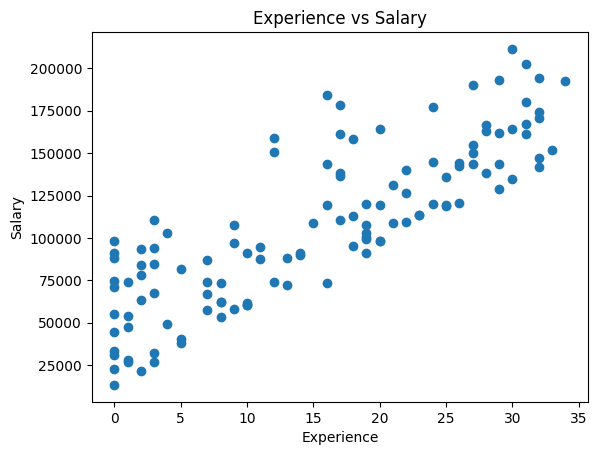

In [23]:
import matplotlib.pyplot as plt

# Experience vs Salary
plt.scatter(df['Experience'], df['Salary'])
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

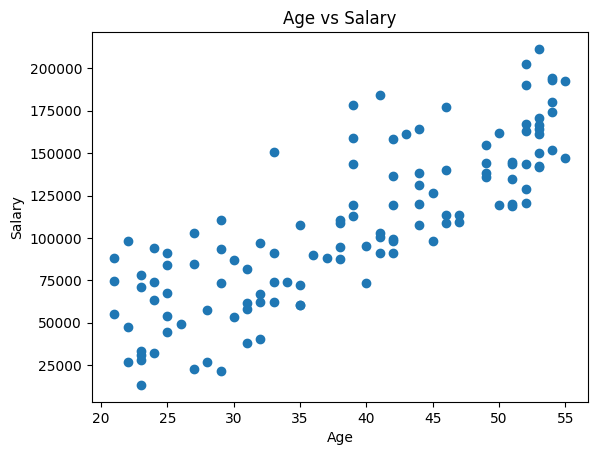

In [24]:
# Age vs Salary
plt.scatter(df['Age'], df['Salary'])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.show()

# Data Preprocessing

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Education'] = le.fit_transform(df['Education'])
df['JobRole'] = le.fit_transform(df['JobRole'])
print(df.head())

   Age  Education  Experience  JobRole  HoursPerWeek  Salary
0   33          2          10       10            43   90897
1   21          1           0        2            41   88350
2   52          1          31       11            55  167324
3   23          0           2        5            47   78372
4   38          1          11        0            51   87716


# Supervised Learning

In [26]:
from sklearn.model_selection import train_test_split

X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Implement 2 Algorithms

In [27]:
#Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [28]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Training Predictions

In [29]:
# Linear Regression
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

# Random Forest
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

In [30]:
from sklearn.metrics import r2_score

# Linear Regression
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

# Random Forest
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("Linear Regression - Train:", train_r2_lr, "Test:", test_r2_lr)
print("Random Forest - Train:", train_r2_rf, "Test:", test_r2_rf)

Linear Regression - Train: 0.7707666467663727 Test: 0.7404518703679998
Random Forest - Train: 0.9624274030754033 Test: 0.7033829254408909


# Comparison + Metrics

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

print("\n Random Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Linear Regression:
MAE: 21699.073757326143
MSE: 569077551.876824
R2 Score: 0.7404518703679998

 Random Forest:
MAE: 20756.547083333335
MSE: 650353824.0645126
R2 Score: 0.7033829254408909


# Visualization Comparison

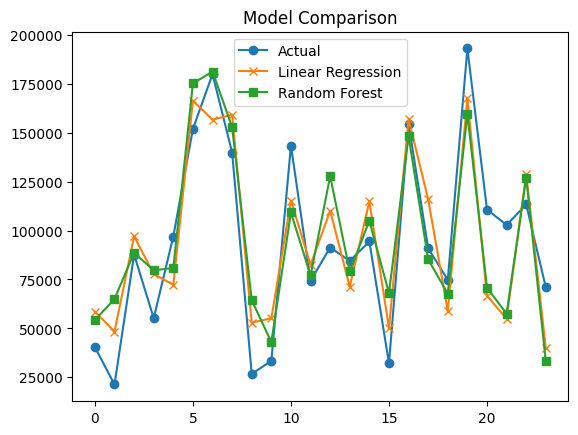

In [32]:
import numpy as np

plt.plot(range(len(y_test)), y_test.values, label="Actual", marker='o')
plt.plot(range(len(y_test)), y_pred_lr, label="Linear Regression", marker='x')
plt.plot(range(len(y_test)), y_pred_rf, label="Random Forest", marker='s')

plt.legend()
plt.title("Model Comparison")
plt.show()